In [1]:
from core import altopt, plot_altopt
from core import DataContext, ParameterContext
import os

In [2]:
from core import get_final_interpolator

In [3]:
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_7"
DATASET3 = DataContext(
    sim_time = os.path.join(DATA_DIR, "t_array.csv"),
    sim_freq = os.path.join(DATA_DIR, "delz_MHz.csv"),
    sim_by = os.path.join(DATA_DIR, "dely_MHz.csv"),
    sim_intensities = sorted([
        os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0.01_dely_") and f.endswith(".csv")
    ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0])),
    exp_time = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\t_exp_70mus.csv",
    exp_freq_axis = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Y_MHz.csv",
    exp_data = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Prb_trans_Exp_70mus.csv",
    save_path = r"Results\Dataset_7\29_Jan\Test_1",
    interpolator=r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_7\sim_interpolator_new_normalisation_linear_0.25_threshold.pkl",
    Aligned = True
)
DEFAULT_ALTOPT_PARAMS = ParameterContext(
    num_iter=3,
    curr_time = 5.0,
    max_time = 70.0,
    t_step = 0.2,
    fixed_by_estimate=0.17,
    fixed_bz_estimate=0.08,
    print_plot = False
)

In [4]:
get_final_interpolator(DATASET3, DEFAULT_ALTOPT_PARAMS)

...Building Final Interpolator...
Time taken to load Interpolator: 0.47938013076782227


(array([0.0000e+00, 1.0000e-03, 2.0000e-03, ..., 6.8959e+01, 6.8960e+01,
        6.8961e+01], shape=(68962,)),
 array([-2.412 , -2.3584, -2.3048, -2.2512, -2.1976, -2.144 , -2.0904,
        -2.0368, -1.9832, -1.9296, -1.876 , -1.8224, -1.7688, -1.7152,
        -1.6616, -1.608 , -1.5544, -1.5008, -1.4472, -1.3936, -1.34  ,
        -1.2864, -1.2328, -1.1792, -1.1256, -1.072 , -1.0184, -0.9648,
        -0.9112, -0.8576, -0.804 , -0.7504, -0.6968, -0.6432, -0.5896,
        -0.536 , -0.4824, -0.4288, -0.3752, -0.3216, -0.268 , -0.2144,
        -0.1608, -0.1072, -0.0536,  0.    ,  0.0536,  0.1072,  0.1608,
         0.2144,  0.268 ,  0.3216,  0.3752,  0.4288,  0.4824,  0.536 ,
         0.5896,  0.6432,  0.6968,  0.7504,  0.804 ,  0.8576,  0.9112,
         0.9648,  1.0184,  1.072 ,  1.1256,  1.1792,  1.2328,  1.2864,
         1.34  ,  1.3936,  1.4472,  1.5008,  1.5544,  1.608 ,  1.6616,
         1.7152,  1.7688,  1.8224,  1.876 ,  1.9296,  1.9832,  2.0368,
         2.0904,  2.144 ,  2.1976,  2

In [5]:
Test = f"1_Starting with {DEFAULT_ALTOPT_PARAMS.curr_time} us_T Step {DEFAULT_ALTOPT_PARAMS.t_step} us"
DEFAULT_ALTOPT_PARAMS.Test = Test

In [ ]:
results = altopt(DATASET3, DEFAULT_ALTOPT_PARAMS)

Starting Adaptive Experiment...
...Building Final Interpolator...
Time taken to load Interpolator: 0.5688774585723877
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Prb_trans_Exp_70mus.csv...
0.18996763229370117 was the time taken to load exp data.
0.09124517440795898 was the time taken to compute the likelihood.| 
 T=5.2s | Bias=0.000 | Est=-0.58925 | StdDev=6.0e-01 | Res=2.5e-04 0.29094958305358887 was the time taken to compute the KL optimisation. 0.048308610916137695 was the time taken to compute the likelihood.| 
 T=5.4s | Bias=0.643 | Est=0.14850 | StdDev=1.7e-01 | Res=2.5e-04 0.26261329650878906 was the time taken to compute the KL optimisation. 0.04120469093322754 was the time taken to compute the likelihood.| 
 T=5.6s | Bias=-0.214 | Est=0.55650 | StdDev=1.5e-02 | Res=2.5e-04 0.2327582836151123 was the time taken to compute the KL optimisation. 0.037003517150878906 was the time taken to compute the likelihood.| 
 T=5.8s | Bias=-0.482 | Es

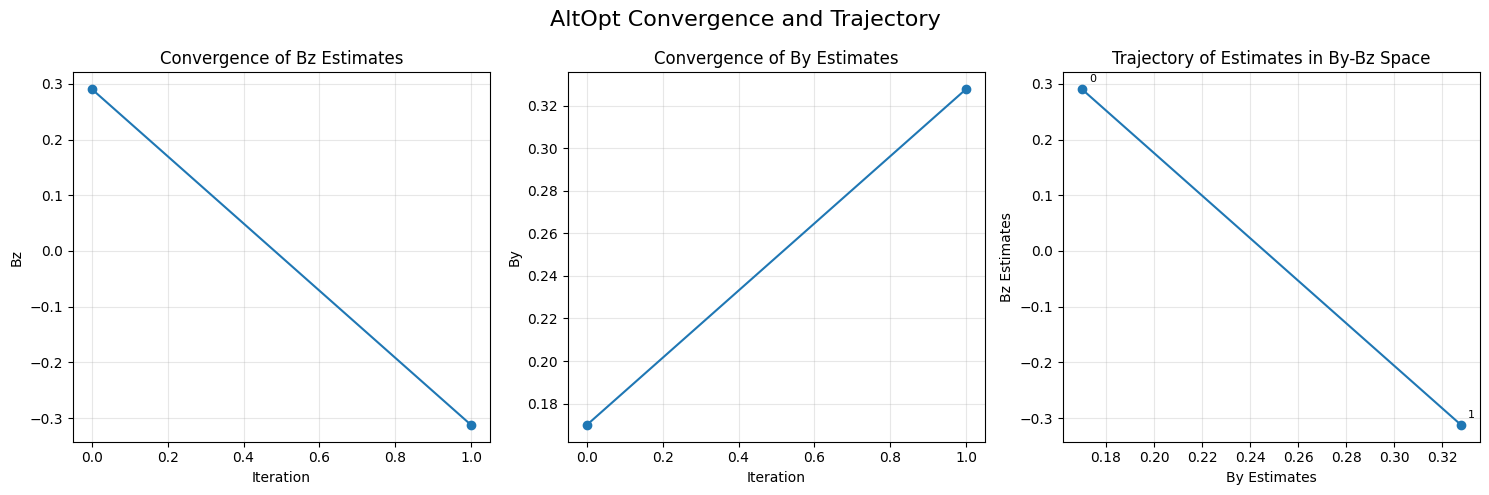

[0.29050000000000004, -0.31224349692628156] [0.17, 0.32775]


<Figure size 640x480 with 0 Axes>

In [7]:
results[1].pop(0)  # remove first estimated by value for plotting consistency
plot_altopt(DATASET3, *results)
print(*results)

In [15]:
Test = f"Y_first_Starting with {DEFAULT_ALTOPT_PARAMS.curr_time} us_T Step {DEFAULT_ALTOPT_PARAMS.t_step} us"
DEFAULT_ALTOPT_PARAMS.Test = Test

In [ ]:
DEFAULT_ALTOPT_PARAMS.Est_First_Z=False
results = altopt(DATASET3, DEFAULT_ALTOPT_PARAMS)
plot_altopt(DATASET3, *results)
print(*results)

...Starting Adaptive Experiment for Y Estimation...
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv...
  > Exp Start: 2.4400s
0.08358001708984375 was the time taken to load exp data.
...Building Final Interpolator...
Time taken to load Interpolator: 0.10823941230773926
0 1999 1999 T=0.1 | BiasZ=0.000 | Est By=0.07300 | Std=0.1440| Res=2.5e-04
KL Calculation Time: 0.02978038787841797
0 1999 1999 T=0.3 | BiasZ=-2.412 | Est By=0.10000 | Std=0.1081| Res=2.5e-04
KL Calculation Time: 0.026162147521972656
23 1999 1976 T=0.4 | BiasZ=1.876 | Est By=0.10000 | Std=0.0546| Res=2.5e-04
KL Calculation Time: 0.02564215660095215
122 1803 1681 T=0.6 | BiasZ=1.286 | Est By=0.10000 | Std=0.0248| Res=2.5e-04
KL Calculation Time: 0.028898239135742188
163 1188 1025 T=0.8 | BiasZ=0.965 | Est By=0.10000 | Std=0.0132| Res=2.5e-04
KL Calculation Time: 0.026279449462890625
185 876 691 T=0.9 | BiasZ=0.804 | Est By=0.10000 | Std=0.0076| Res=2.5e-04
KL Calculation Time: 